In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



Matplotlib is building the font cache; this may take a moment.


In [2]:
customer_df = pd.read_csv(r"C:\Users\Lenovo\Customer-Intelligence-Platform\data\processed\customer_summary_clean.csv")
order_df = pd.read_csv(r"C:\Users\Lenovo\Customer-Intelligence-Platform\data\processed\order_summary_clean.csv")
product_df = pd.read_csv(r"C:\Users\Lenovo\Customer-Intelligence-Platform\data\processed\product_summary_clean.csv")
seller_df = pd.read_csv(r"C:\Users\Lenovo\Customer-Intelligence-Platform\data\processed\seller_summary_clean.csv")

In [6]:
customer_df.head(3)

,customer_unique_id,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,first_purchase,last_purchase,customer_lifetime_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,1.0,12.00,141.90,5.0,6.0,2018-05-10,2018-05-10,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,1.0,8.29,27.19,4.0,3.0,2018-05-07,2018-05-07,0
2,0000f46a3911fa3c0805444483337064,1,86.22,1.0,17.22,86.22,3.0,26.0,2017-03-10,2017-03-10,0


In [7]:
order_df.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,total_items,distinct_sellers,total_product_price,total_freight,total_payment,product_payment,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0,-9.0,1,1,58.9,13.29,72.19,58.9,5.0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0,-3.0,1,1,239.9,19.93,259.83,239.9,4.0
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.0,-14.0,1,1,199.0,17.87,216.87,199.0,5.0


In [8]:
product_df.head(3)

,product_id,product_category_name,total_units_sold,total_orders,total_revenue,total_freight,avg_price,avg_review_score,avg_delivery_days
0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria,1,1,101.65,18.59,101.65,5.0,17.0
1,00088930e925c41fd95ebfe695fd2655,automotivo,1,1,129.90,13.93,129.90,4.0,11.0
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_banho,1,1,229.00,13.10,229.00,1.0,16.0


In [9]:
seller_df.head(3)

,seller_id,seller_city,seller_state,total_orders,total_units_sold,total_revenue,total_freight,avg_product_price,avg_review_score,avg_delivery_days
0,0015a82c2db000af6aaaf3ae2ecb0532,santo andre,SP,3,3,2685.00,63.06,895.00,3.67,10.67
1,001cca7ae9ae17fb1caed9dfb1094831,cariacica,ES,200,239,25080.03,8854.14,104.94,3.90,13.11
2,001e6ad469a905060d959994f1b41e4f,sao goncalo,RJ,1,1,250.00,17.94,250.00,1.00,NaN


## Customer Visual EDA

### 1. Distribution of Customer Spending - Histogram

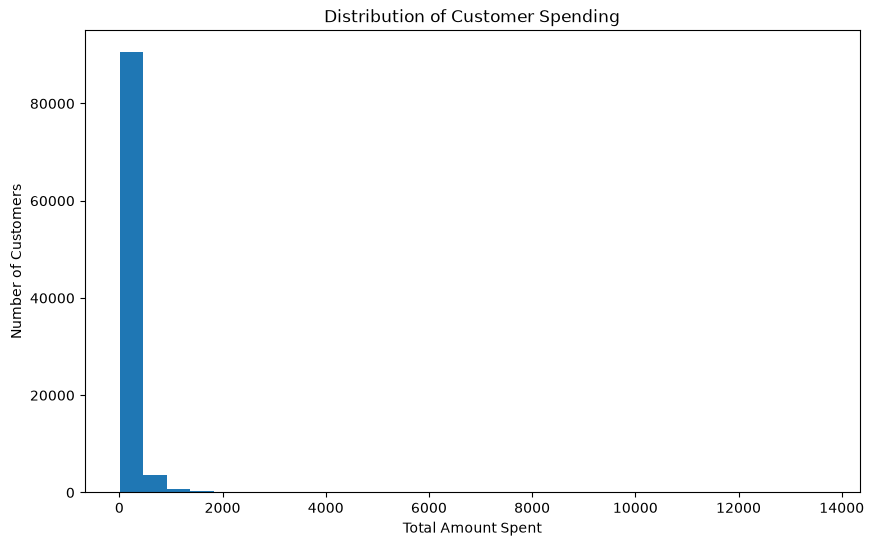

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(customer_df["total_spent"], bins=30)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Amount Spent")
plt.ylabel("Number of Customers")

plt.show()

Now calculating the descriptive statistics

In [18]:
customer_df["total_spent"].describe()

count    95419.000000
mean       166.070491
std        228.341907
min          9.590000
25%         63.100000
50%        107.950000
75%        183.270000
max      13664.080000
Name: total_spent, dtype: float64

In [19]:
print("Mean  :", customer_df["total_spent"].mean())
print("Median:", customer_df["total_spent"].median())
print("Std   :", customer_df["total_spent"].std())
print("Skew  :", customer_df["total_spent"].skew())

Mean  : 166.0704908875591
Median: 107.95
Std   : 228.3419074120333
Skew  : 9.08694310355458


In [20]:
customer_df["total_spent"].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

0.25      63.1000
0.50     107.9500
0.75     183.2700
0.90     319.1100
0.95     473.8530
0.99    1113.5944
Name: total_spent, dtype: float64

### 2. Distribution of customer spending - Boxplot

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26424\534002071.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


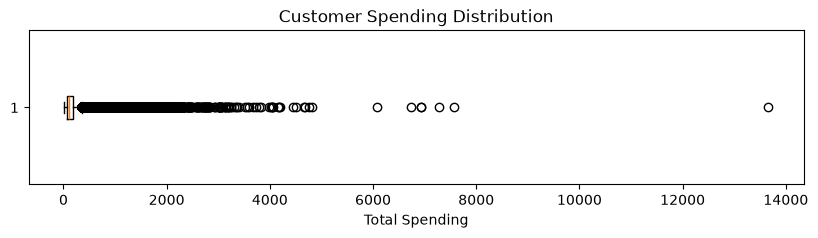

In [21]:
plt.figure(figsize=(10,2))

plt.boxplot(
    customer_df["total_spent"],
    vert=False
)

plt.title("Customer Spending Distribution")

plt.xlabel("Total Spending")

plt.show()

Customer spending is highly concentrated. While the majority of customers make relatively small purchases, a small segment of high-value customers contributes disproportionately large transaction amounts. These premium customers represent an important opportunity for retention strategies, personalized recommendations, and loyalty programs.

### 3. Total order distribution

#### Descriptive statistics

In [24]:
customer_df["total_orders"].describe()

count    95419.000000
mean         1.034018
std          0.211235
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         16.000000
Name: total_orders, dtype: float64

In [25]:
print("Mean :", customer_df["total_orders"].mean())
print("Median :", customer_df["total_orders"].median())
print("Mode :", customer_df["total_orders"].mode()[0])
print("Skew :", customer_df["total_orders"].skew())

Mean : 1.034018382083233
Median : 1.0
Mode : 1
Skew : 11.44154900930785


#### Histogram visualization

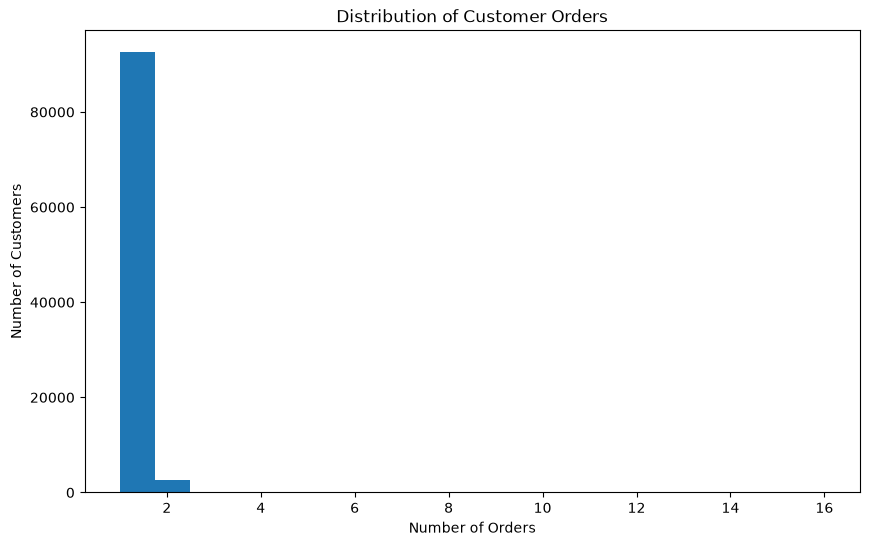

In [26]:
plt.figure(figsize=(10,6))

plt.hist(
    customer_df["total_orders"],
    bins=20
)

plt.title("Distribution of Customer Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26424\2183858830.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


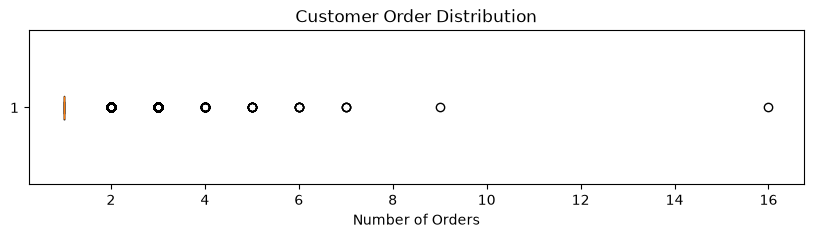

In [27]:
plt.figure(figsize=(10,2))

plt.boxplot(
    customer_df["total_orders"],
    vert=False
)

plt.title("Customer Order Distribution")

plt.xlabel("Number of Orders")

plt.show()

#### Frequency Table

In [28]:
(
    customer_df["total_orders"]
    .value_counts()
    .sort_index()
    .reset_index(name="customers")
)

,total_orders,customers
0,1,92506
1,2,2673
2,3,192
3,4,29
4,5,9
5,6,5
6,7,3
7,9,1
8,16,1


### 4. Average order value (AOV) analysis

#### 1. Descriptive statistics

In [29]:
customer_df["avg_order_value"].describe()

count    95419.000000
mean       161.073799
std        221.208569
min          9.590000
25%         62.440000
50%        105.780000
75%        177.150000
max      13664.080000
Name: avg_order_value, dtype: float64

In [30]:
print("Mean  :", customer_df["avg_order_value"].mean())
print("Median:", customer_df["avg_order_value"].median())
print("Std   :", customer_df["avg_order_value"].std())
print("Skew  :", customer_df["avg_order_value"].skew())

Mean  : 161.07379882413355
Median: 105.78
Std   : 221.2085690756083
Skew  : 9.278306009434905


#### 2. Percentile

In [31]:
customer_df["avg_order_value"].quantile(
    [0.25,0.50,0.75,0.90,0.95,0.99]
)

0.25      62.4400
0.50     105.7800
0.75     177.1500
0.90     307.9400
0.95     450.9940
0.99    1069.3758
Name: avg_order_value, dtype: float64

#### 3. Histogram

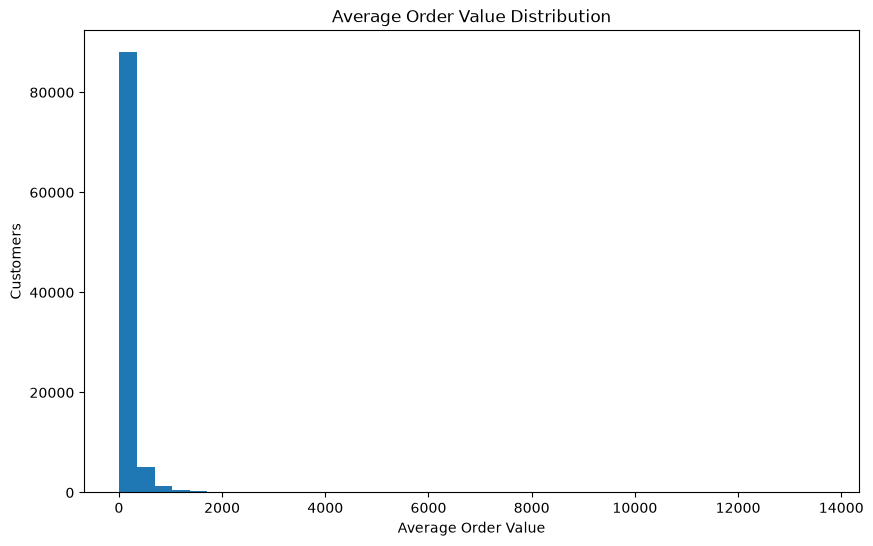

In [32]:
plt.figure(figsize=(10,6))

plt.hist(
    customer_df["avg_order_value"],
    bins=40
)

plt.title("Average Order Value Distribution")
plt.xlabel("Average Order Value")
plt.ylabel("Customers")

plt.show()

### 5. Customer satisfaction (customer review) analysis

#### 1. Descriptive statistics

In [33]:
customer_df["avg_review_score"].describe()

count    94720.000000
mean         4.102521
std          1.326359
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: avg_review_score, dtype: float64

In [34]:
print("Mean :", customer_df["avg_review_score"].mean())
print("Median :", customer_df["avg_review_score"].median())
print("Mode :", customer_df["avg_review_score"].mode()[0])
print("Std :", customer_df["avg_review_score"].std())
print("Skew :", customer_df["avg_review_score"].skew())

Mean : 4.102521431587838
Median : 5.0
Mode : 5.0
Std : 1.3263593292413896
Skew : -1.3910341682930392


In [35]:
customer_df["avg_review_score"].quantile(
    [0.25,0.50,0.75,0.90,0.95,0.99]
)

0.25    4.0
0.50    5.0
0.75    5.0
0.90    5.0
0.95    5.0
0.99    5.0
Name: avg_review_score, dtype: float64

#### 2. Histogram

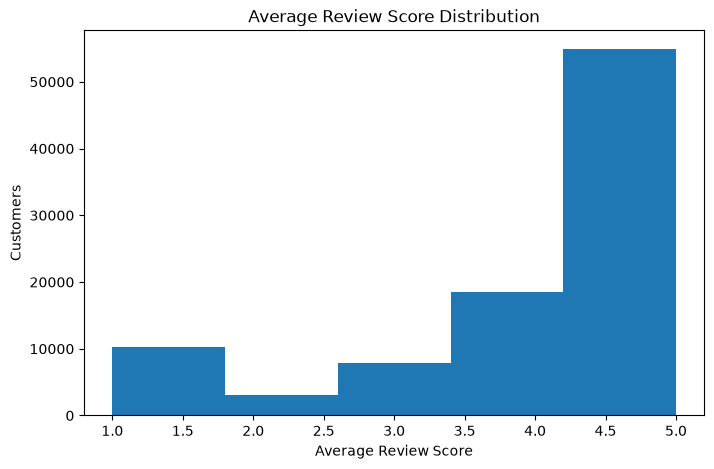

In [42]:
plt.figure(figsize=(8,5))

plt.hist(
    customer_df["avg_review_score"],
    bins=5
)

plt.title("Average Review Score Distribution")

plt.xlabel("Average Review Score")

plt.ylabel("Customers")

plt.show()

#### 3. Boxplot

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26424\2027417973.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


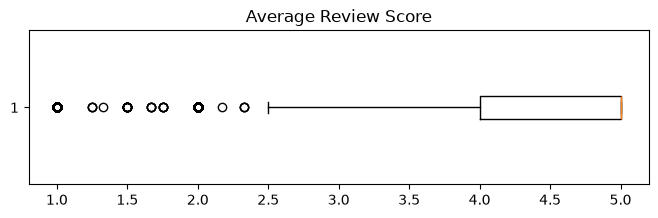

In [44]:
plt.figure(figsize=(8,2))

plt.boxplot(
    customer_df["avg_review_score"].dropna(),
    vert=False
)

plt.title("Average Review Score")

plt.show()

### 6. Average delivary Days

#### 1, Descriptive statistics

In [45]:
customer_df["avg_delivery_days"].describe()

count    93355.000000
mean        12.506692
std          9.554535
min          0.000000
25%          7.000000
50%         10.000000
75%         16.000000
max        210.000000
Name: avg_delivery_days, dtype: float64

In [46]:
print("Mean :", customer_df["avg_delivery_days"].mean())
print("Median :", customer_df["avg_delivery_days"].median())
print("Mode :", customer_df["avg_delivery_days"].mode()[0])
print("Std :", customer_df["avg_delivery_days"].std())
print("Skew :", customer_df["avg_delivery_days"].skew())

Mean : 12.506691767982431
Median : 10.0
Mode : 7.0
Std : 9.554535105553224
Skew : 3.879707567317795


In [47]:
customer_df["avg_delivery_days"].quantile(
    [0.25,0.50,0.75,0.90,0.95,0.99]
)

0.25     7.0
0.50    10.0
0.75    16.0
0.90    23.0
0.95    29.0
0.99    46.0
Name: avg_delivery_days, dtype: float64

#### 2. Histogram

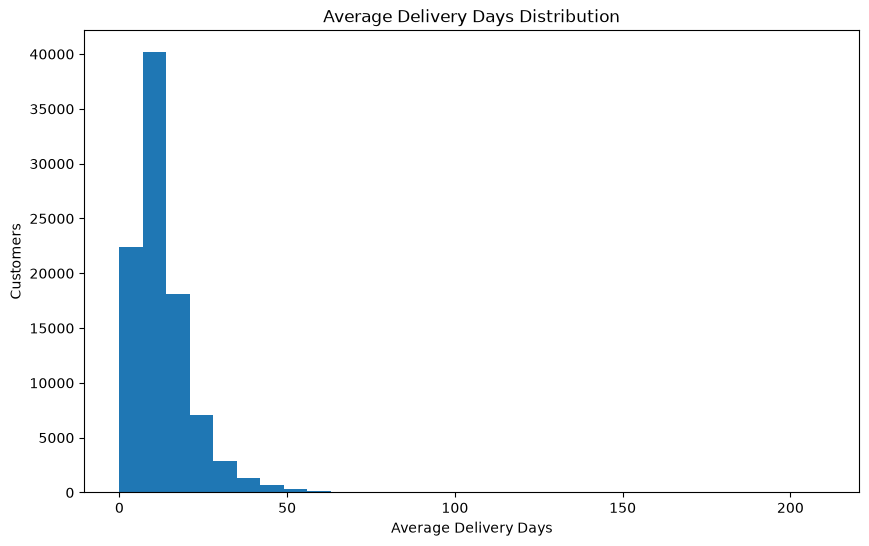

In [48]:
plt.figure(figsize=(10,6))

plt.hist(
    customer_df["avg_delivery_days"].dropna(),
    bins=30
)

plt.title("Average Delivery Days Distribution")
plt.xlabel("Average Delivery Days")
plt.ylabel("Customers")

plt.show()

#### 3. Boxplot

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26424\3513946090.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


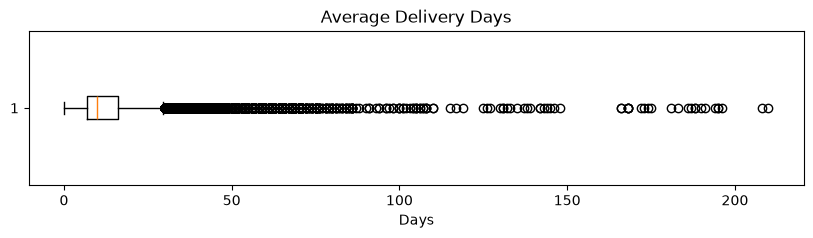

In [49]:
plt.figure(figsize=(10,2))

plt.boxplot(
    customer_df["avg_delivery_days"].dropna(),
    vert=False
)

plt.title("Average Delivery Days")

plt.xlabel("Days")

plt.show()

## Bivariate Analysis

### 1. Correlation Matrix

In [50]:

numeric_customer = customer_df.select_dtypes(
    include=["number"]
)

corr_matrix = numeric_customer.corr()

corr_matrix.round(2)

,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,customer_lifetime_days
total_orders,1.00,0.12,0.44,0.21,-0.01,0.01,-0.00,0.61
total_spent,0.12,1.00,0.23,0.51,0.98,-0.05,0.07,0.07
total_products,0.44,0.23,1.00,0.48,0.16,-0.10,-0.02,0.26
total_freight_paid,0.21,0.51,0.48,1.00,0.47,-0.08,0.16,0.12
avg_order_value,-0.01,0.98,0.16,0.47,1.00,-0.05,0.07,-0.01
avg_review_score,0.01,-0.05,-0.10,-0.08,-0.05,1.00,-0.34,0.02
avg_delivery_days,-0.00,0.07,-0.02,0.16,0.07,-0.34,1.00,-0.01
customer_lifetime_days,0.61,0.07,0.26,0.12,-0.01,0.02,-0.01,1.00


#### Relationship 1: Delivery Time vs Review Score
Do customers who wait longer for delivery tend to give lower ratings?

In [51]:
delivery_review = customer_df[
    ["avg_delivery_days", "avg_review_score"]
].dropna()

In [52]:
corr = delivery_review["avg_delivery_days"].corr(
    delivery_review["avg_review_score"]
)

print(f"Correlation: {corr:.3f}")

Correlation: -0.335


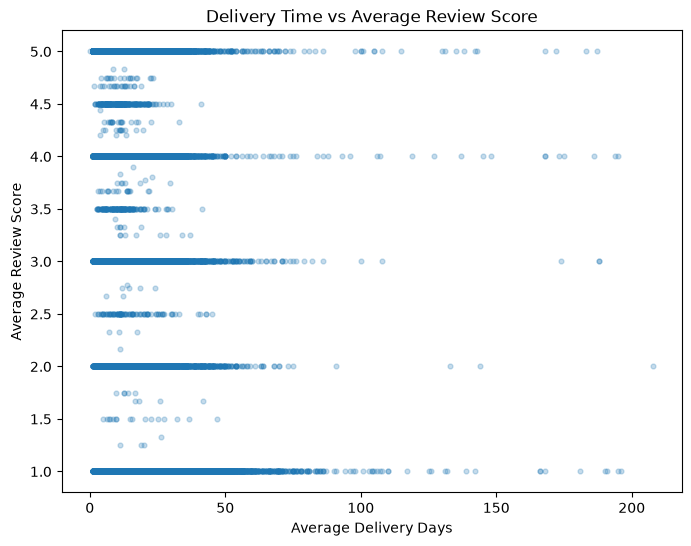

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(
    delivery_review["avg_delivery_days"],
    delivery_review["avg_review_score"],
    alpha=0.25,
    s=12
)

plt.title("Delivery Time vs Average Review Score")

plt.xlabel("Average Delivery Days")

plt.ylabel("Average Review Score")

plt.show()

### Relationship 2: Total Orders vs Customer Lifetime days

In [57]:
lifetime_orders = customer_df[
    ["customer_lifetime_days", "total_orders"]
].dropna()

In [58]:
corr = lifetime_orders["customer_lifetime_days"].corr(
    lifetime_orders["total_orders"]
)

print(f"Correlation: {corr:.3f}")

Correlation: 0.606


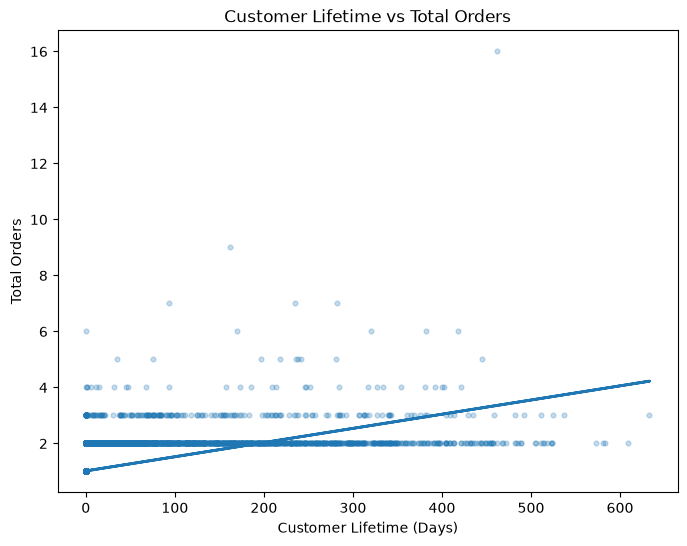

In [59]:
import numpy as np
import matplotlib.pyplot as plt

x = lifetime_orders["customer_lifetime_days"]
y = lifetime_orders["total_orders"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,6))

plt.scatter(
    x,
    y,
    alpha=0.25,
    s=12
)

plt.plot(
    x,
    m*x+b,
    linewidth=2
)

plt.title("Customer Lifetime vs Total Orders")

plt.xlabel("Customer Lifetime (Days)")
plt.ylabel("Total Orders")

plt.show()